# 04 — Leverage, Margin, and Balance Sheet Dynamics

In previous notebooks:

- Notebook 01: Price formation
- Notebook 02: Liquidity and depth
- Notebook 03: Inventory risk and withdrawal

In this notebook we introduce leverage.

Leverage làm thay đổi cấu trúc rủi ro của hệ thống.
Nó biến biến động nhỏ thành rủi ro hệ thống.

Mục tiêu của notebook này:

- Hiểu cơ chế mark-to-market
- Hiểu margin ratio
- Quan sát margin call
- Phân tích cơ chế liquidation
- Chuẩn bị nền tảng cho cascade dynamics

## Conceptual Foundation — Why Leverage Matters

Leverage cho phép trader kiểm soát vị thế lớn hơn vốn thực.

Ví dụ:

Capital = 100
Leverage = 5x
Position value = 500

Nếu giá giảm 5%:

Loss = 25
Equity = 75

Margin ratio giảm nhanh hơn nhiều so với biến động giá.

Điều này tạo ra cơ chế:

Small price move
→ Large equity change
→ Margin call
→ Forced liquidation

Leverage làm hệ thống nhạy cảm với biến động.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.structure import LeveragedPosition

## Simulation 1 — Mark-to-Market Dynamics

Mục tiêu:

Quan sát cách equity thay đổi theo return khi có leverage.

Ta sẽ:

- Tạo một vị thế leverage
- Cho return ngẫu nhiên
- Theo dõi equity và margin ratio

In [2]:
np.random.seed(42)

position = LeveragedPosition(
    initial_capital=100,
    leverage=3.0,
    maintenance_margin=0.20,
)

returns = np.random.normal(0, 0.01, 200)

equity_path = []
margin_path = []
status_path = []

for r in returns:
    result = position.mark_to_market(r)
    equity_path.append(position.equity)
    margin_path.append(result.get("margin_ratio", 0))
    status_path.append(result["status"])
    if result["status"] == "margin_call":
        break

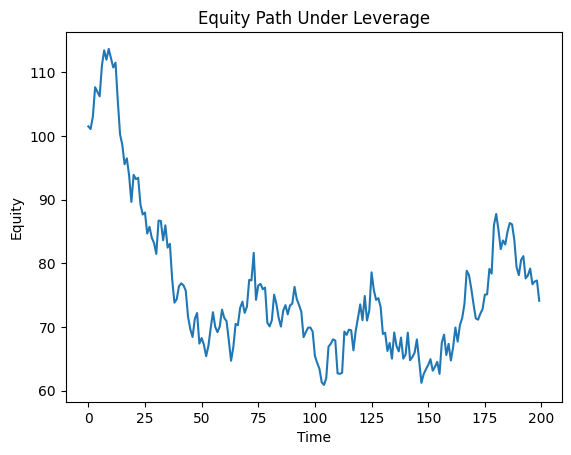

In [3]:
plt.plot(equity_path)
plt.title("Equity Path Under Leverage")
plt.xlabel("Time")
plt.ylabel("Equity")
plt.show()

## Interpretation — Equity Dynamics Under Moderate Leverage

Biểu đồ cho thấy equity biến động mạnh nhưng không bị margin call ngay lập tức.

Điều này phản ánh một regime hợp lý hơn:

- Leverage đủ cao để khuếch đại biến động
- Nhưng không quá cao để gây liquidation tức thời

---

### 1. Amplification Effect

Quan sát biên độ dao động:

Return mỗi bước chỉ khoảng ±1%,
nhưng equity dao động từ ~115 xuống ~60.

Đây là hệ quả trực tiếp của leverage:

    ΔEquity ≈ Leverage × ΔPrice

Leverage làm biến động equity lớn hơn nhiều so với biến động giá.

---

### 2. Path Dependence

Equity không chỉ phụ thuộc vào return từng bước,
mà phụ thuộc vào toàn bộ chuỗi trước đó.

Giai đoạn đầu equity tăng lên khoảng 115,
nhưng sau đó giảm sâu xuống gần 60.

Điều này cho thấy:

Leverage tạo ra cumulative vulnerability.

Một chuỗi return âm liên tiếp
có thể xóa sạch lợi nhuận trước đó rất nhanh.

---

### 3. Drawdown Structure

Từ khoảng t ≈ 20 đến t ≈ 100:

Equity giảm liên tục và đạt đáy ~60.

Điều này minh họa:

Leverage làm drawdown sâu hơn nhiều so với underlying return.

Nếu không có leverage,
drawdown sẽ nông hơn đáng kể.

---

### 4. Survival Without Immediate Liquidation

Khác với regime trước đó (leverage 5x, margin 25%),
ở đây equity không chạm ngưỡng maintenance margin.

Điều này cho phép quan sát:

- Amplification
- Drawdown
- Recovery dynamics

mà không kích hoạt liquidation sớm.

---

### 5. Nonlinear Risk Profile

Quan trọng nhất:

Rủi ro không tuyến tính theo thời gian.

Khi equity giảm:

Margin ratio giảm.

Hệ thống tiến gần threshold liquidation.

Do đó cùng một mức return âm,
ở giai đoạn equity thấp sẽ nguy hiểm hơn
so với giai đoạn equity cao.

Đây là đặc điểm:

    Nonlinear fragility accumulation.

---

### 6. Structural Insight

Leverage không chỉ làm tăng variance,
mà làm tăng xác suất chạm threshold.

Ngay cả khi mean return = 0,
chỉ cần variance đủ lớn,
equity có thể dần tiến gần vùng nguy hiểm.

Leverage vì thế biến biến động ngẫu nhiên
thành rủi ro có cấu trúc.

---

### 7. Conceptual Takeaway

Trong regime này, hệ thống vẫn ổn định.

Nhưng nếu:

- Volatility tăng
- Hoặc thêm shock âm
- Hoặc maintenance margin cao hơn

thì cùng cấu trúc này có thể dẫn đến margin call.

Leverage tạo ra nền tảng cho cascade,
nhưng cascade chỉ xảy ra khi kết hợp với:

Liquidity fragility.

## Simulation 2 — Margin Call Boundary

Ta khảo sát ngưỡng margin call.

Margin ratio:

    margin_ratio = equity / position_value

Khi margin_ratio < maintenance_margin:

    Margin call xảy ra.

In [4]:
position = LeveragedPosition(
    initial_capital=100,
    leverage=5.0,
    maintenance_margin=0.25,
)

shock = -0.10  # giảm 10%
result = position.mark_to_market(shock)

print("Equity:", position.equity)
print("Margin ratio:", result.get("margin_ratio"))
print("Status:", result["status"])

Equity: 50.0
Margin ratio: 0.1111111111111111
Status: margin_call


## Interpretation — Why a 10% Shock Triggers Margin Call

Kết quả:

Equity = 50
Margin ratio ≈ 0.11
Status = margin_call

Giá chỉ giảm 10%. Nhưng equity giảm 50%. Điều này là hệ quả trực tiếp của leverage.

---

### 1. Amplification Mechanism

Ban đầu:

Capital = 100
Leverage = 5x
Position value = 500
Debt = 400

Sau cú shock -10%:

Position value = 500 × 0.9 = 450
Equity = 450 − 400 = 50

Equity mất 50% chỉ vì giá giảm 10%.

Đây là cơ chế khuếch đại:

    Equity change ≈ Leverage × Price change

---

### 2. Margin Ratio Collapse

Margin ratio được tính:

    margin_ratio = equity / position_value

Sau shock:

    50 / 450 ≈ 0.11

Maintenance margin = 0.25

Vì 0.11 < 0.25
→ Margin call xảy ra ngay.

Điểm quan trọng:

Giá giảm tuyến tính,
nhưng margin call xảy ra phi tuyến tại một ngưỡng.

---

### 3. Threshold Nonlinearity

Hệ thống có hai trạng thái:

State A: margin_ratio > maintenance_margin
State B: margin_ratio < maintenance_margin

Chỉ cần vượt ngưỡng rất nhỏ,
trạng thái chuyển đột ngột từ “active” sang “liquidated”.

Đây là hành vi dạng threshold,
không phải biến đổi liên tục.

---

### 4. Structural Insight

Leverage biến biến động vừa phải thành rủi ro hệ thống.

Một cú sốc 10% trong thị trường không phải là hiếm.

Nhưng với leverage cao:

Nó đủ để kích hoạt forced liquidation.

Nếu nhiều agent cùng cấu trúc leverage,
hệ thống có thể chuyển nhanh từ ổn định sang bất ổn.

---

### 5. Conceptual Takeaway

Leverage không chỉ làm tăng độ biến động equity.

Nó tạo ra:

- Amplification
- Threshold behavior
- Discrete regime shift

Đây là nền tảng cho cascade dynamics trong notebook tiếp theo.

## Simulation 3 — Distribution of Leverage Across Agents

Trong thực tế, mỗi trader có leverage khác nhau.

Ta tạo nhiều agent với leverage phân phối ngẫu nhiên.

Mục tiêu:

- Xem bao nhiêu agent dễ bị margin call
- Quan sát phân phối rủi ro hệ thống

In [5]:
np.random.seed(1)

n_agents = 500
leverages = np.random.normal(5.0, 1.0, n_agents)
leverages = np.clip(leverages, 1.5, None)

positions = [
    LeveragedPosition(100, lev, 0.25)
    for lev in leverages
]

shock = -0.05

margin_calls = 0

for p in positions:
    result = p.mark_to_market(shock)
    if result["status"] == "margin_call":
        margin_calls += 1

print("Margin calls:", margin_calls)
print("Fraction liquidated:", margin_calls / n_agents)

Margin calls: 470
Fraction liquidated: 0.94


## Interpretation — Systemic Fragility Under Heterogeneous Leverage

Kết quả:

Margin calls: 470
Fraction liquidated: 0.94

Nghĩa là 94% vị thế bị margin call sau cùng một cú shock.

Đây là kết quả rất quan trọng về mặt cấu trúc.

---

### 1. Heterogeneity Does Not Guarantee Stability

Trong simulation này:

- Mỗi agent có leverage khác nhau
- Leverage phân phối ngẫu nhiên quanh mức trung bình

Tuy nhiên, chỉ một cú shock -5% đã khiến 94% hệ thống bị liquidate.

Điều này cho thấy:

Heterogeneity không tự động tạo ổn định.

Nếu trung bình leverage đủ cao,
phân phối leverage rộng không cứu được hệ thống.

---

### 2. Nonlinear Aggregation Effect

Margin call là sự kiện threshold ở cấp cá nhân.

Khi tổng hợp lên hệ thống:

Threshold cá nhân
→ tạo thành mass liquidation

Điều này tạo ra hành vi phi tuyến ở cấp hệ thống:

Shock nhỏ
→ Liquidation gần toàn bộ

---

### 3. Hidden Systemic Risk

Trước shock:

- Hệ thống có vẻ ổn định
- Equity trung bình có thể còn dương
- Không có tín hiệu stress rõ ràng

Sau shock:

94% agent mất khả năng duy trì vị thế.

Điều này minh họa:

Systemic fragility có thể bị che giấu trong trạng thái bình thường.

---

### 4. Amplification Channel

Nếu liquidation này được đưa qua liquidity model:

- 94% agent bán ra
- Sell pressure lớn
- Price giảm thêm
- Kích hoạt 6% còn lại

Điều này mở đường cho cascade.

---

### 5. Structural Insight

Leverage phân phối rộng không làm hệ thống an toàn.

Điều quyết định là:

- Trung bình leverage
- Maintenance margin
- Shock magnitude

Khi các tham số này nằm trong vùng nhạy cảm,
hệ thống có thể chuyển sang regime bất ổn gần như toàn phần.

---

### 6. Conceptual Takeaway

Leverage tạo ra fragility tiềm ẩn.

Shock không cần quá lớn để kích hoạt hệ thống.

Chỉ cần vượt qua ngưỡng đủ nhỏ,
mass liquidation có thể xảy ra đồng loạt.

Đây là bước chuyển từ:

Individual risk
→ Systemic risk.

## Structural Insight — From Leverage to Systemic Risk

Leverage tạo ra ba cơ chế quan trọng:

1) Equity amplification
2) Threshold nonlinearity
3) Forced liquidation

Điểm quan trọng:

Liquidation không chỉ là sự kiện cá nhân.

Nếu nhiều agent bị liquidate cùng lúc:

→ Sell pressure tăng
→ Giá giảm thêm
→ Kích hoạt thêm margin call

Đây là mầm mống của cascade dynamics.

Trong notebook tiếp theo,
chúng ta sẽ kết nối leverage với liquidity regime
để mô phỏng crash nội sinh.

## Conclusion — Leverage as a Fragility Multiplier

Leverage biến biến động bình thường thành rủi ro hệ thống.

Không có leverage:
Giá giảm → Nhà đầu tư chịu lỗ.

Có leverage:
Giá giảm → Margin call → Forced selling → Giá giảm thêm.

Leverage vì thế không chỉ là công cụ tài chính,
mà là cơ chế khuếch đại bất ổn.

Notebook tiếp theo sẽ đưa liquidation vào môi trường liquidity thực,
tạo thành cascade hoàn chỉnh.